<center> <font size = 10> Unsupervised Learning - Credit Card Customer Segmentation </center> </font>

# **Problem statement**

**Context**

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help



**Objective**

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.



**Data Description**

The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).


**Data Dictionary**

Sl_No: Primary key of the records</br>
Customer Key: Customer identification number</br>
Average Credit Limit: Average credit limit of each customer for all credit cards</br>
Total credit cards: Total number of credit cards possessed by the customer</br>
Total visits bank: Total number of visits that the customer made (yearly) personally to the bank</br>
Total visits online: Total number of visits or online logins made by the customer (yearly)</br>
Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

# **Installing and Importing Necessary Libraries and functions**

In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

# **Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_excel('/content/drive/MyDrive/Python/Credit Card Customer Data.xlsx')

# **Data Overview**

This gives us a basic and important information of our dataset.  The initial
steps to understand a dataset is to:

* Observe the first few rows of the dataset to check whether the
dataset is loaded properly or not.
* Get information about the rows and columns in the dataset.
* Find out the data types and non-null value counts of the column .
* Check the statistical summary of the dataset to get an overview of
the numerical columns of the data.

## Displaying the first few rows of the dataset

In [5]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


*  The dataset is loaded successfully.
*  The dataset provided information about average credit limit of customers, total credit cards possessed by customers, total number of visits made by customers to the bank.

## Checking the shape of the dataset

In [6]:
df.shape

(660, 7)

*  The dataset consists of 660 rows and 7 columns.

## Checking the data types of the columns for the dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


*  There are 7 interger type variables.

## Statistical summary of the dataset

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


*  The minimum number of credit cards possesed by customers is 1 and the maximum number of credit cards is 10.
*  The average number of visits to the bank is 2.4. The minimum number of visits is 0 and the maximum number is 5.
*  Average credit limit ranges from 3000 to 200000. The max values implies of outliers in this column.
*  The minimum number of online visits is 1 and the maximum is 15 which indicates of outliers.
*  The average of total calls made by customer is 3.58.

# **Exploratory Data Analysis**

In [9]:
def histogram_boxplot(data, feature, figsize=(10, 8), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    f2.suptitle(f"Distribution of {feature}", fontsize=16, fontweight='bold')
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="purple", linestyle="-"
    )  # Add median to the histogram

In [10]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

## Univariate Analysis

### Distribution of `Avg_Credit_Limit`

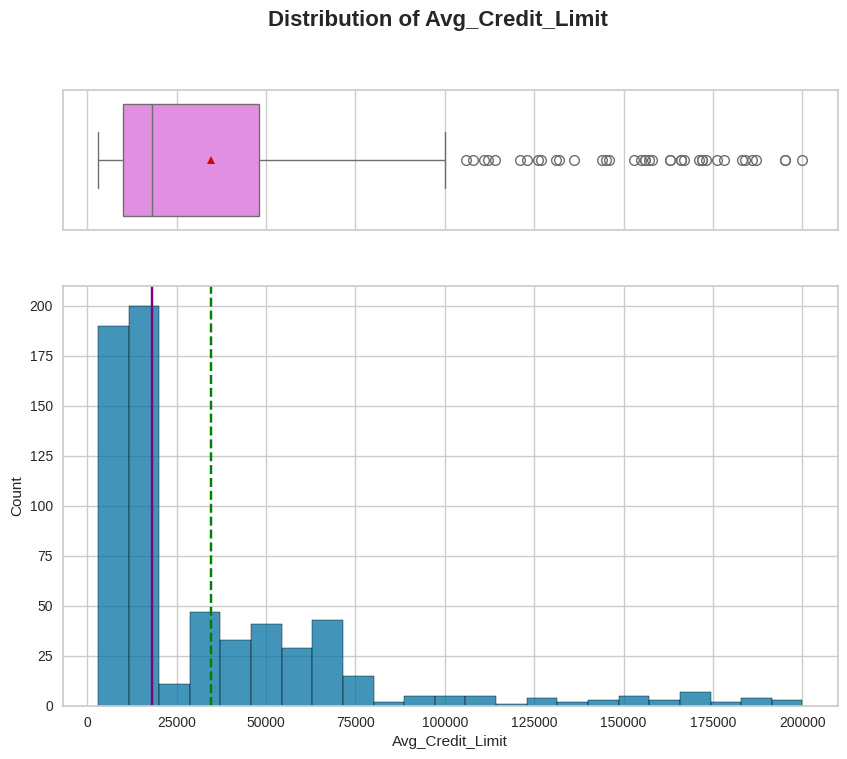

In [11]:
histogram_boxplot(df, "Avg_Credit_Limit")


*  Average credit limit is right skewed.
*  Most of the values are concentrated between 10000 - 750000.
*  The extreme higher values indicate some customers have high average credit limit.

### Distribution of `Total_Credit_Cards`

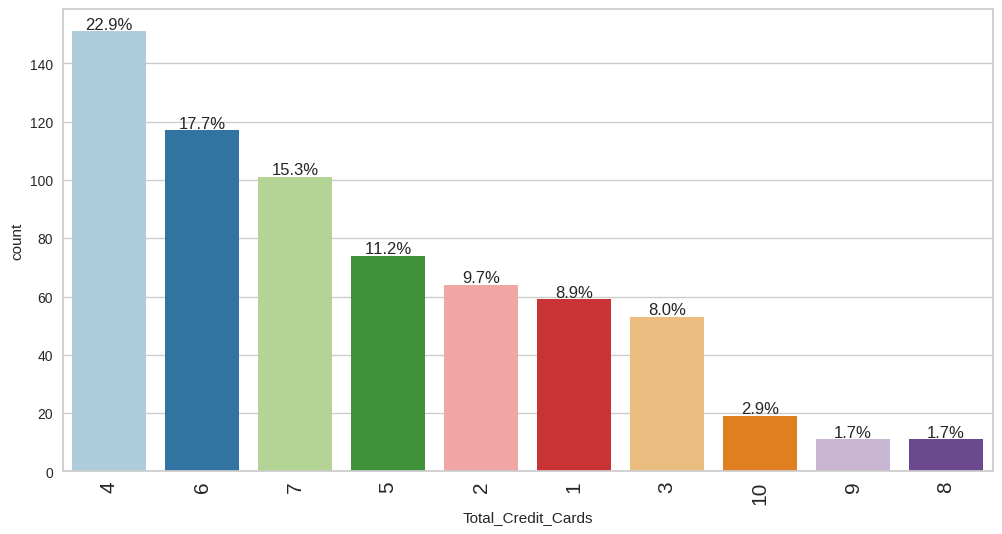

In [12]:
labeled_barplot(df, 'Total_Credit_Cards', perc=True)
plt.show()

*  Most customers hold 4 credit cards at 22.9%, followed by 6 credit cards at 17.7% and 7 credit cards at 15.3%.
*  Customers possessing more than 8 credit card is less than 3%.

### Distribution of `Total_visits_bank`

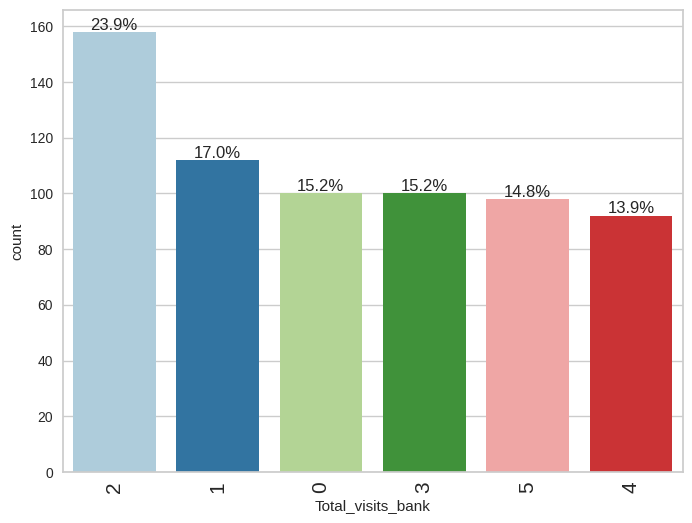

In [13]:
labeled_barplot(df, 'Total_visits_bank', perc=True)
plt.show()

*  Most customers visit the bank about twice(23.9%).
*  Many customers come once(17.04%).
*  About 15% of customers do not visit branches.

### Distribution of `Total_Visits_online`

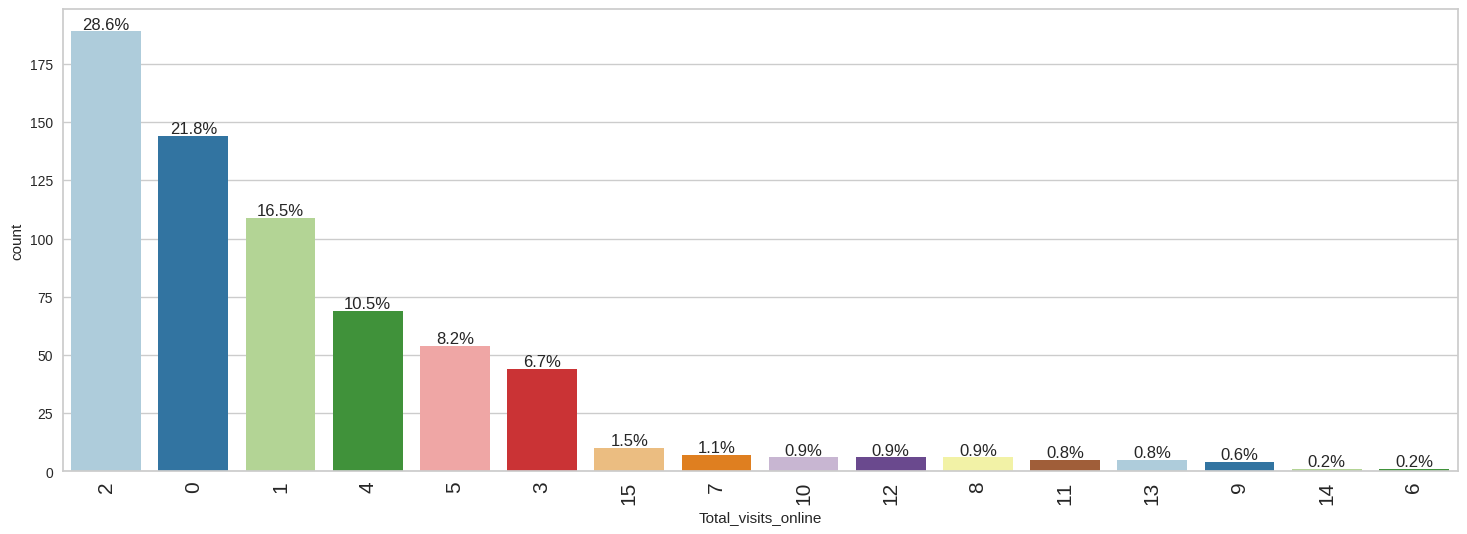

In [14]:
labeled_barplot(df, 'Total_visits_online', perc=True)
plt.show()

*  Most customers visit the online logins about twice(28.6%).
*  Many customers login once(16.5%).
*  About 21.8% of customers did not login online.
*  10.5% of the customers visited online 4 times.
*  More than 5 online visits are less than 10%.

### Distribution of `Total_calls_made`

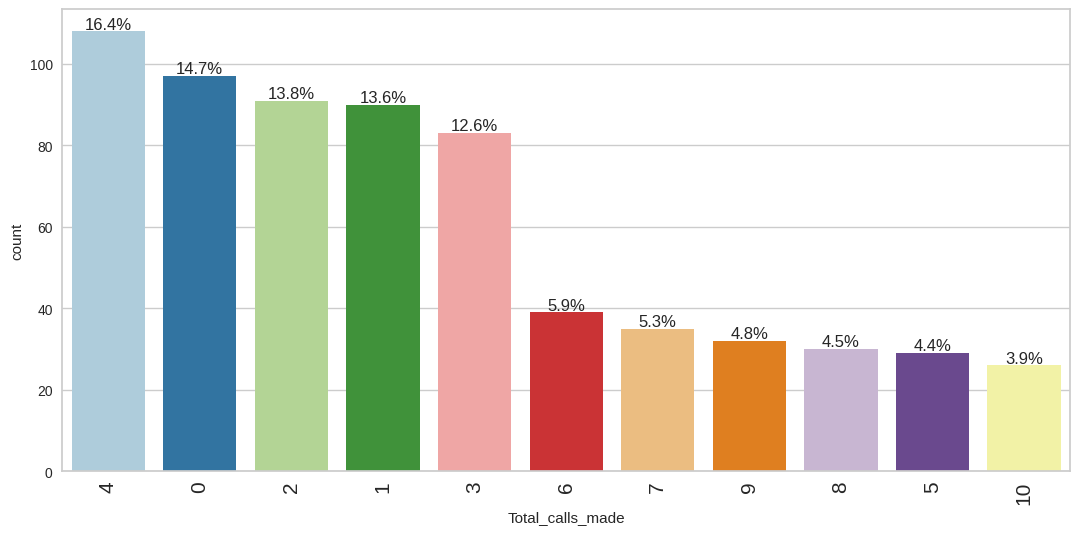

In [16]:
labeled_barplot(df, 'Total_calls_made', perc=True)
plt.show()

*  Most customers made 4 calls(16.4%).
*  About 14.7% of customers did not make any call.
*  Customers who made 1-3 calls lie between 12% to 14%.
*  Customers who made more than 5 calls are less than 6%.

## Bivariate analysis

### Pairplot

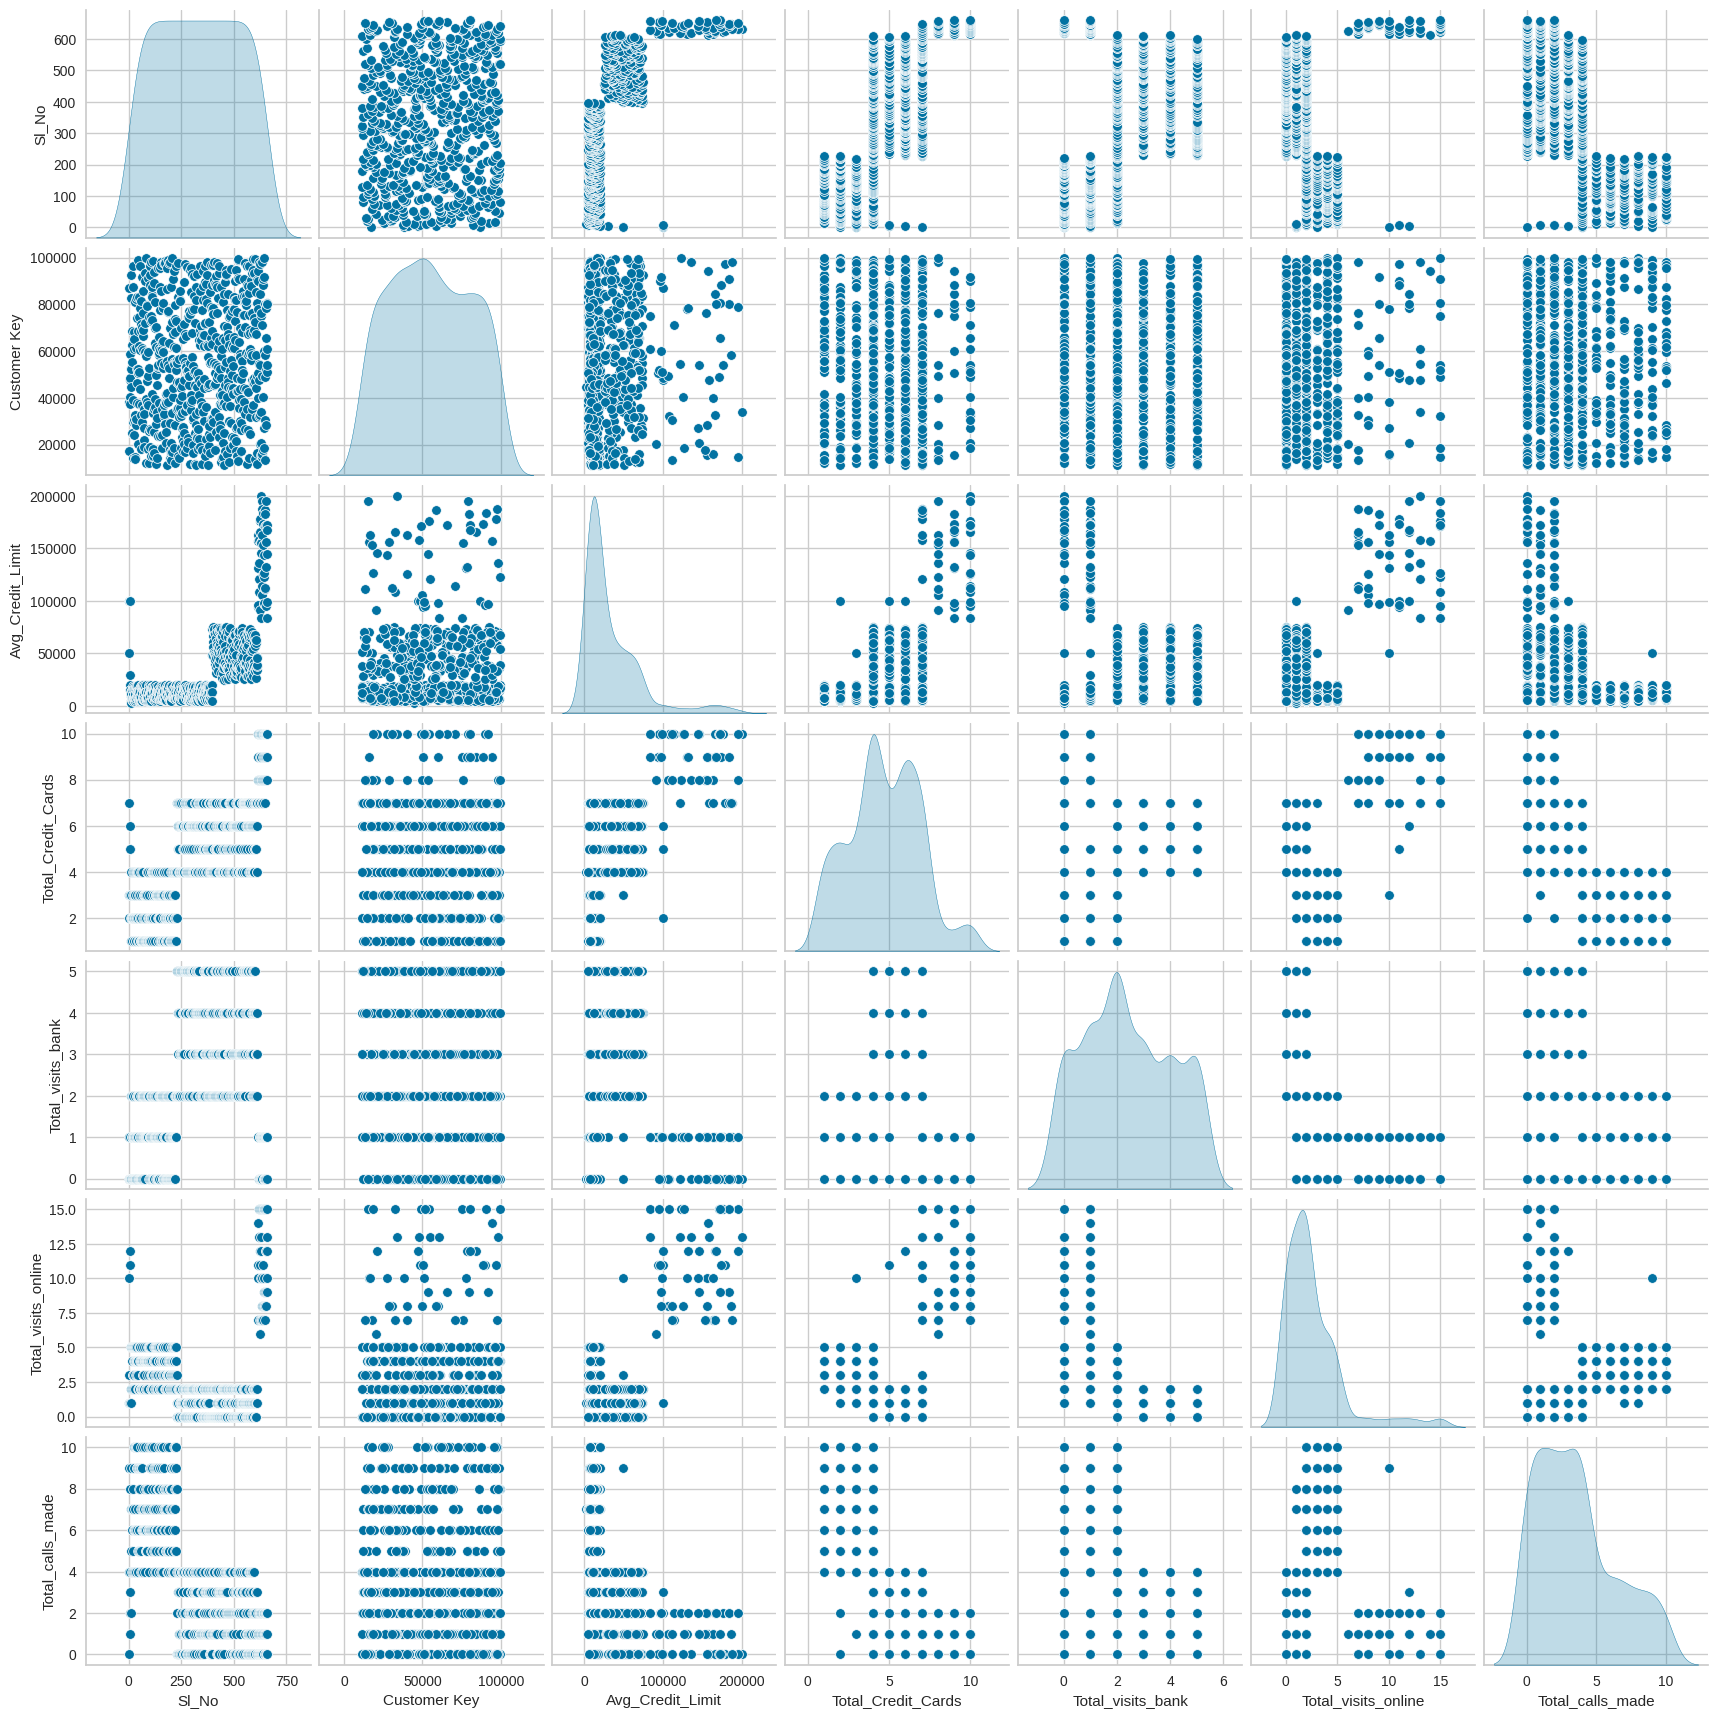

In [17]:
sns.pairplot(df, diag_kind="kde")
plt.show()

### Heatmap

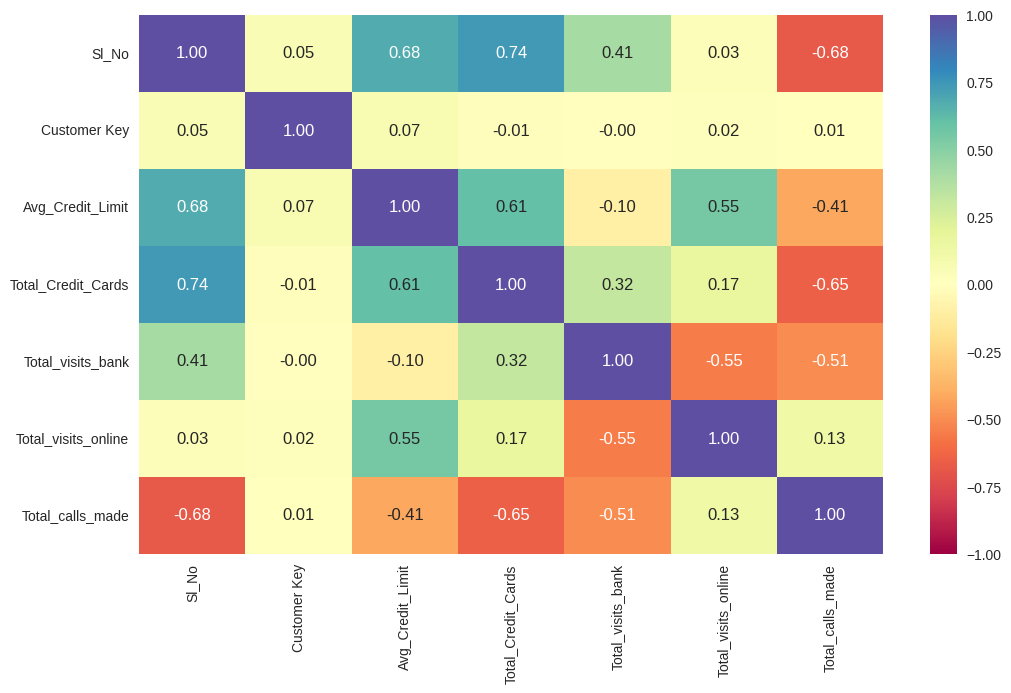

In [18]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1,fmt='.2f', cmap='Spectral')
plt.show()

*  Average Credit Limit and Total Credit Cards are moderately positively correlated (0.61), indicating that customers with higher credit limits tend to own more credit cards.
*  Average Credit Limit and Online Visits show moderate positive correlation (0.55), suggesting that high-credit customers are more active in digital channels.
*  Total Credit Cards and Total Calls Made are strongly negatively correlated (-0.65), implying that customers with more cards tend to contact customer service less.
*  Branch Visits and Online Visits are moderately negatively correlated (-0.55), showing a shift between physical and digital banking behavior.
*  Branch Visits and Calls Made are negatively correlated (-0.51), meaning customers who visit branches more tend to make fewer calls.

# **Data Preprocessing**

## Duplicate value check

In [19]:
df.duplicated().sum()

np.int64(0)

*  There are no duplicate values in our dataset.

## Missing value treatment

In [20]:
df.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


*  There are no missing values in our dataset.

## Outlier check

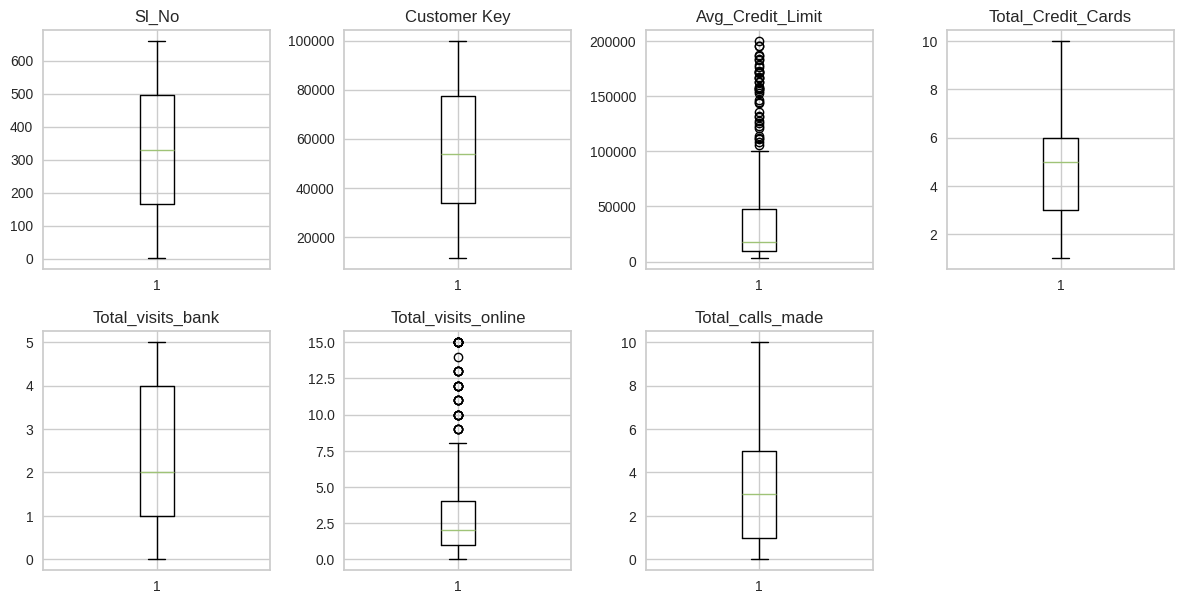

In [21]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 15))

for i, variable in enumerate(numeric_columns):
    plt.subplot(5, 4, i + 1)  # 5 rows, 4 columns
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

*  There are quite a few outliers in the data.
*  However, we will not treat them as they likely represent premium customers and keeping them may help discover a “high-value” cluster.

## Feature Engineering

We'll drop the columns 'Sl_No' and 'Customer Key' as they are unique values.

In [22]:
df = df.drop(columns=['Sl_No', 'Customer Key'])

## Data Scaling

 *  Let's scale the data before we proceed to cluster it. Without scaling, large-range variables (like credit limit) would dominate the distance calculation.
 *  We use StandardScalar to scale the data.

In [23]:
# Scaling the data set before clustering
scaler = StandardScaler()
subset = df.copy()
subset_scaled = scaler.fit_transform(subset)

In [25]:
# Creating a dataframe from the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

In [26]:
subset_scaled_df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


*  Customers with high positive credit limit values (e.g., Rows 0 and 4) represent high-value or premium customers.
*  Most rows show negative values for bank visits, indicating low branch dependency.
*  Rows 1 and 4 have very high online visit scores, showing strong preference for digital banking.
*  Row 1 shows very high call activity, indicating customers who require frequent support.
*  Rows 0 and 4 show low call values, meaning they are mostly self-sufficient.


In [27]:
# creating dataframe copies for k-means and hierarchical clustering
km_df = df.copy()
hc_df = df.copy()

#**K-means Clustering**


## Checking Elbow Plot

Number of Clusters: 1 	Average Distortion: 2.006922226250361
Number of Clusters: 2 	Average Distortion: 1.4571553548514269
Number of Clusters: 3 	Average Distortion: 1.1466276549150365
Number of Clusters: 4 	Average Distortion: 1.0463825294774463
Number of Clusters: 5 	Average Distortion: 0.9907312373999949
Number of Clusters: 6 	Average Distortion: 0.9707323413980713
Number of Clusters: 7 	Average Distortion: 0.9092311283834433
Number of Clusters: 8 	Average Distortion: 0.8845041419695102


Text(0.5, 1.0, 'Selecting k with the Elbow Method')

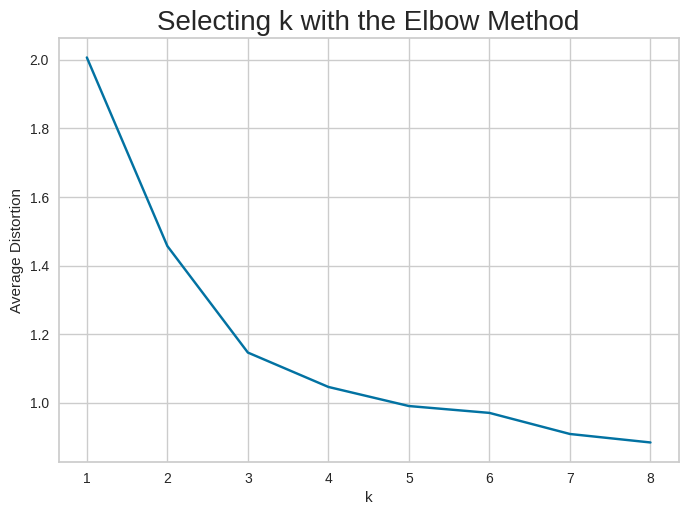

In [28]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)

Let's do further analysis to determine the optimal value of k

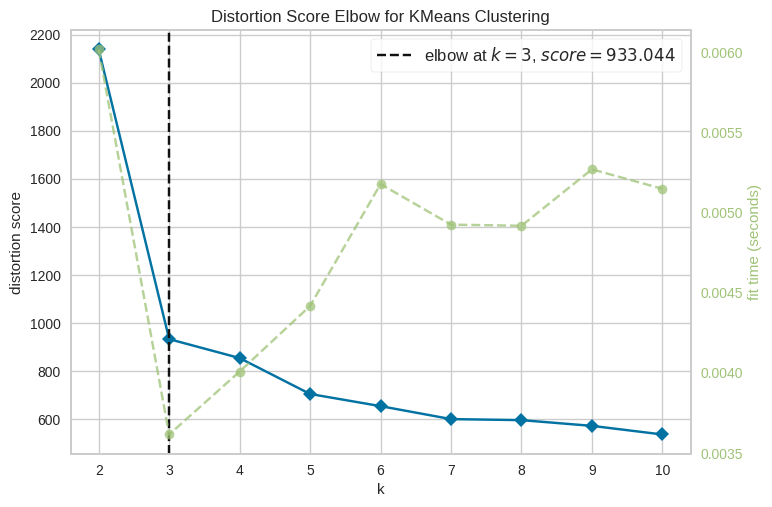

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [29]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), timings=True)
visualizer.fit(subset_scaled_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure

**From the elbow plot, it seems that 3 is the optimal value of k. Let's check the Silhouette scores.**

## Checking Silhouette Scores

For n_clusters = 2, the silhouette score is 0.5703183487340514)
For n_clusters = 3, the silhouette score is 0.5157182558881063)
For n_clusters = 4, the silhouette score is 0.3744071798973986)
For n_clusters = 5, the silhouette score is 0.27167502160723267)
For n_clusters = 6, the silhouette score is 0.24804756291576194)
For n_clusters = 7, the silhouette score is 0.24791254258020035)
For n_clusters = 8, the silhouette score is 0.22570382558070443)
For n_clusters = 9, the silhouette score is 0.19931783829027247)
For n_clusters = 10, the silhouette score is 0.20939001908412339)


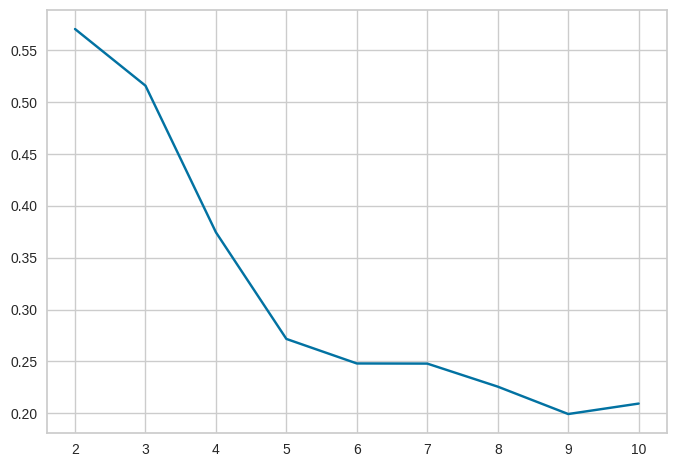

In [30]:
sil_score = []
cluster_list = range(2, 11)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

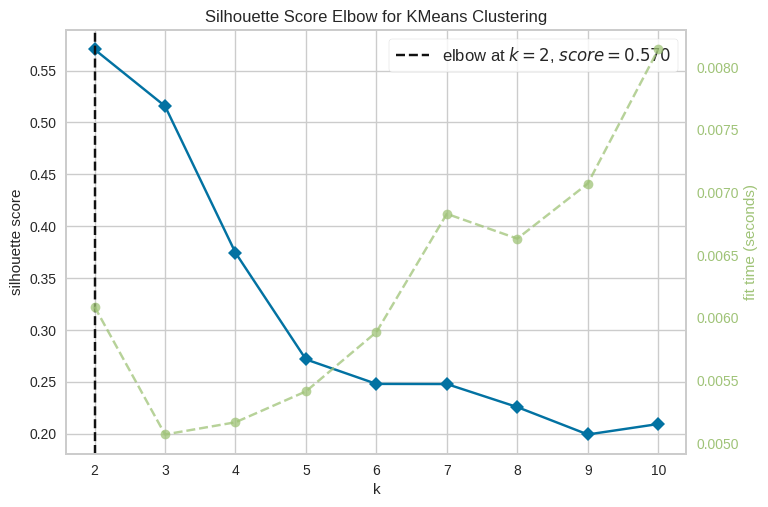

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [31]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), metric="silhouette", timings=True)
visualizer.fit(subset_scaled_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure

**From the silhouette scores, it seems that 2 is a good value for k.**

### Silhouette plot

Let's check Silhouette plot when k= 2, 3 and 4.

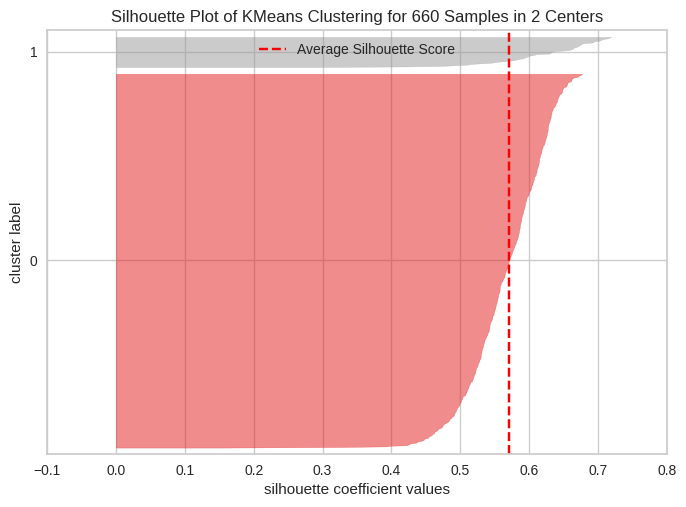

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [32]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

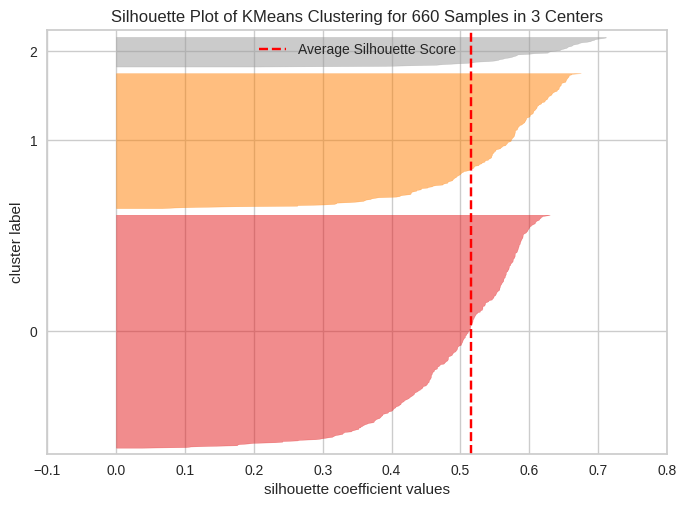

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [33]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

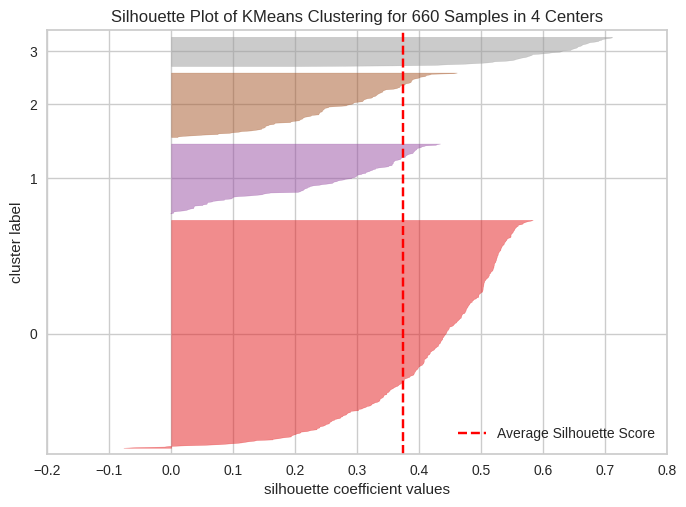

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [34]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

## Selecting final model

**Let's take 3 as the appropriate no. of clusters as the silhouette score is high enough and there is knick at 3 in the elbow curve.**

In [35]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=3, random_state=0)

In [36]:
# adding kmeans cluster labels to the original dataframe
km_df["Cluster"] = kmeans.labels_

In [37]:
km_df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,100000,2,1,1,0,0
1,50000,3,0,10,9,1
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,2


## Cluster Profiling

In [38]:
cluster_profile = km_df.groupby("Cluster").mean()

In [39]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000
1,12174.107143,2.410714,0.933036,3.553571,6.870536
2,141040.000000,8.740000,0.600000,10.900000,1.080000


**Let's plot boxplot to visualize cluster profiles.**

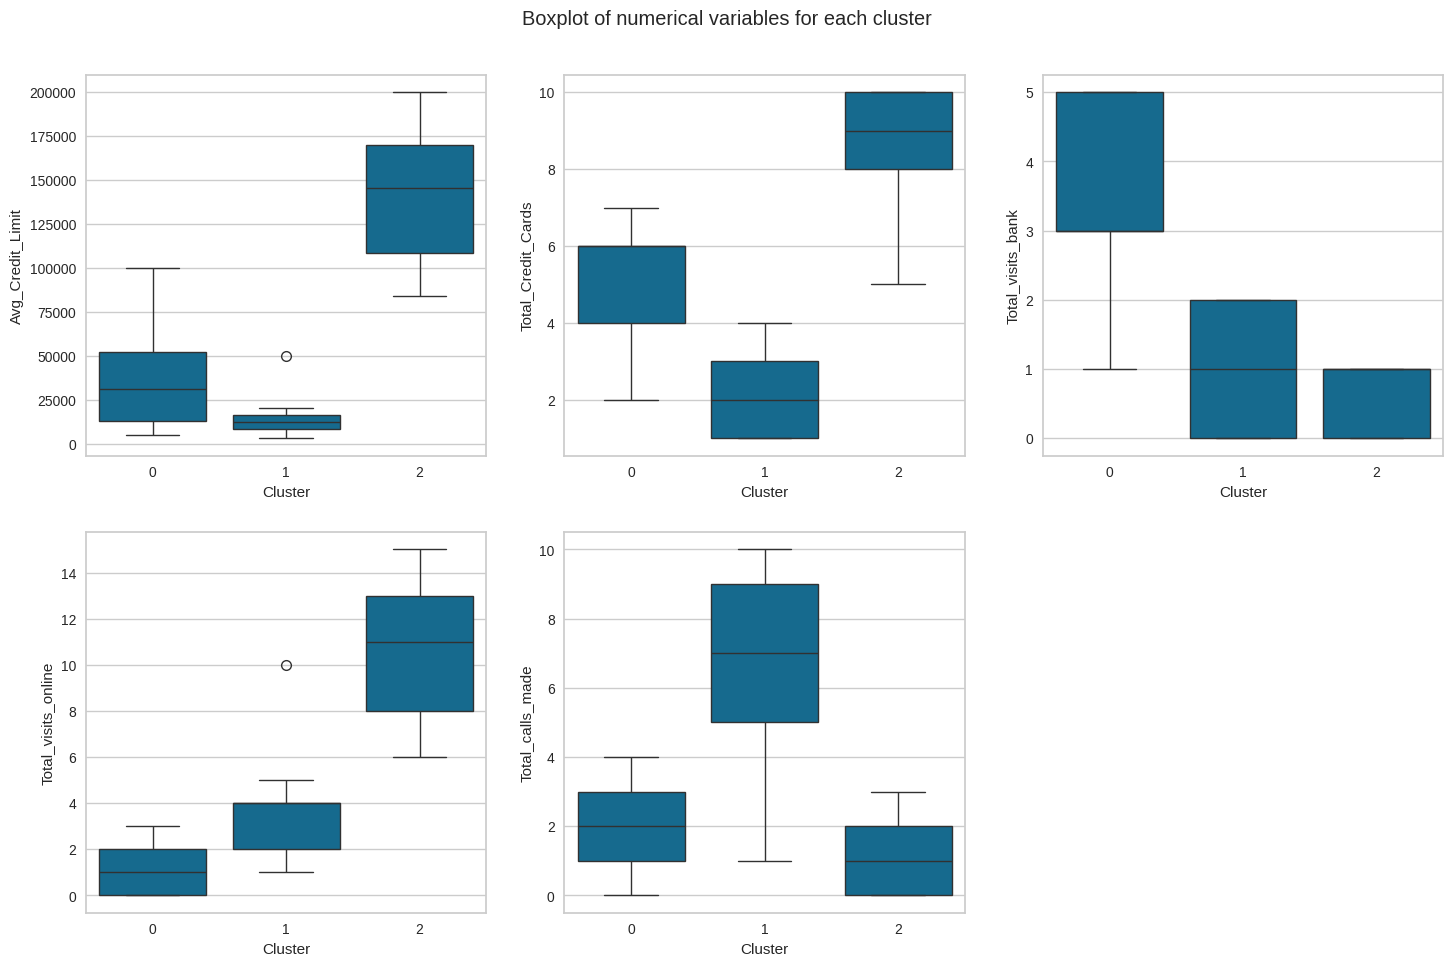

In [40]:
numeric_columns = km_df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Cluster' from the numeric_columns list for plotting
numeric_columns = [col for col in numeric_columns if col != 'Cluster']

plt.figure(figsize=(15, 10))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(numeric_columns):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=km_df, x="Cluster", y=variable) # Changed data=df to data=km_df

plt.tight_layout(pad=2.0)

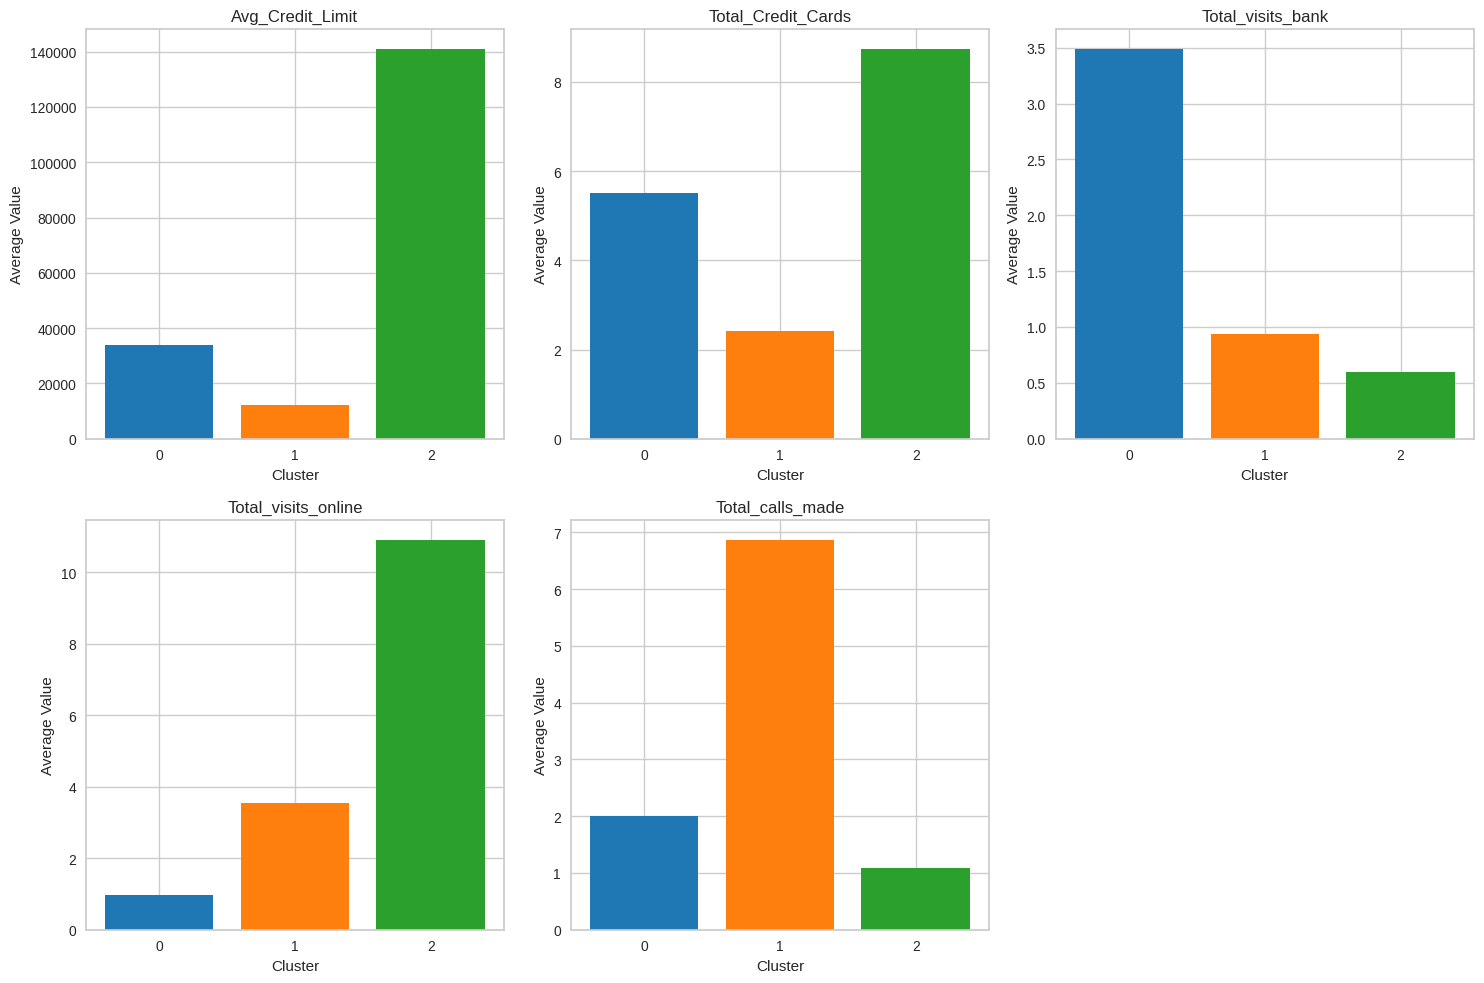

In [41]:
#Get cluster profile
cluster_profile = km_df.groupby("Cluster").mean()

#Define cluster colors (same color for each cluster everywhere)
cluster_colors = ['#1f77b4',  # Cluster 0 → Blue
                  '#ff7f0e',  # Cluster 1 → Orange
                  '#2ca02c']  # Cluster 2 → Green

#Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

#Plot each feature
for i, col in enumerate(cluster_profile.columns):

    axes[i].bar(cluster_profile.index,
                cluster_profile[col],
                color=cluster_colors)

    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Average Value")
    axes[i].set_xticks(cluster_profile.index)

#Remove extra subplot (since 5 features but 6 slots)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Cluster 0 - Balanced**
*  Shows moderate value across all features.
*  Mid credit limit
*  Moderate cards
*  Highest branch visits
*  Low online usage
*  Low calls
*  Prefer physical banking

**Cluster 1 - Low-Value Support-Heavy Customers**

*  Lowest credit limit
*  Few cards
*  Low branch visits
*  Moderate online visits
*  Highest calls
*  Indicates new customers who have lower credit or need more assistance

**Cluster 2 - Premium Digital Users**

*  Represents bank's premium customers
*  Very high credit limit
*  Many cards
*  Very high online usage
*  Very low calls
*  Very low branch visits
*  This profile suggests affluent, digitally-savvy customers who are largely self-sufficient.

# **Hierarchical Clustering**

## Checking Cophenetic Correlation

In [42]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.7391220243806552.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8599730607972423.
Cophenetic correlation for Euclidean distance and average linkage is 0.8977080867389372.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8861746814895477.
Cophenetic correlation for Chebyshev distance and single linkage is 0.7382354769296767.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8533474836336782.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8974159511838106.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8913624010768603.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.7058064784553605.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.6663534463875359.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8326994115042136.
Cophenetic co

**Let's explore different linkage methods with Euclidean distance only.**

In [43]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(subset_scaled_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.7391220243806552.
Cophenetic correlation for complete linkage is 0.8599730607972423.
Cophenetic correlation for average linkage is 0.8977080867389372.
Cophenetic correlation for centroid linkage is 0.8939385846326323.
Cophenetic correlation for ward linkage is 0.7415156284827493.
Cophenetic correlation for weighted linkage is 0.8861746814895477.


In [44]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8977080867389372, which is obtained with Euclidean distance and average linkage.


**We see that the cophenetic correlation is maximum with Euclidean distance and average linkage.**


**Let's view the dendrograms for the different linkage methods.**

## Checking Dendrograms

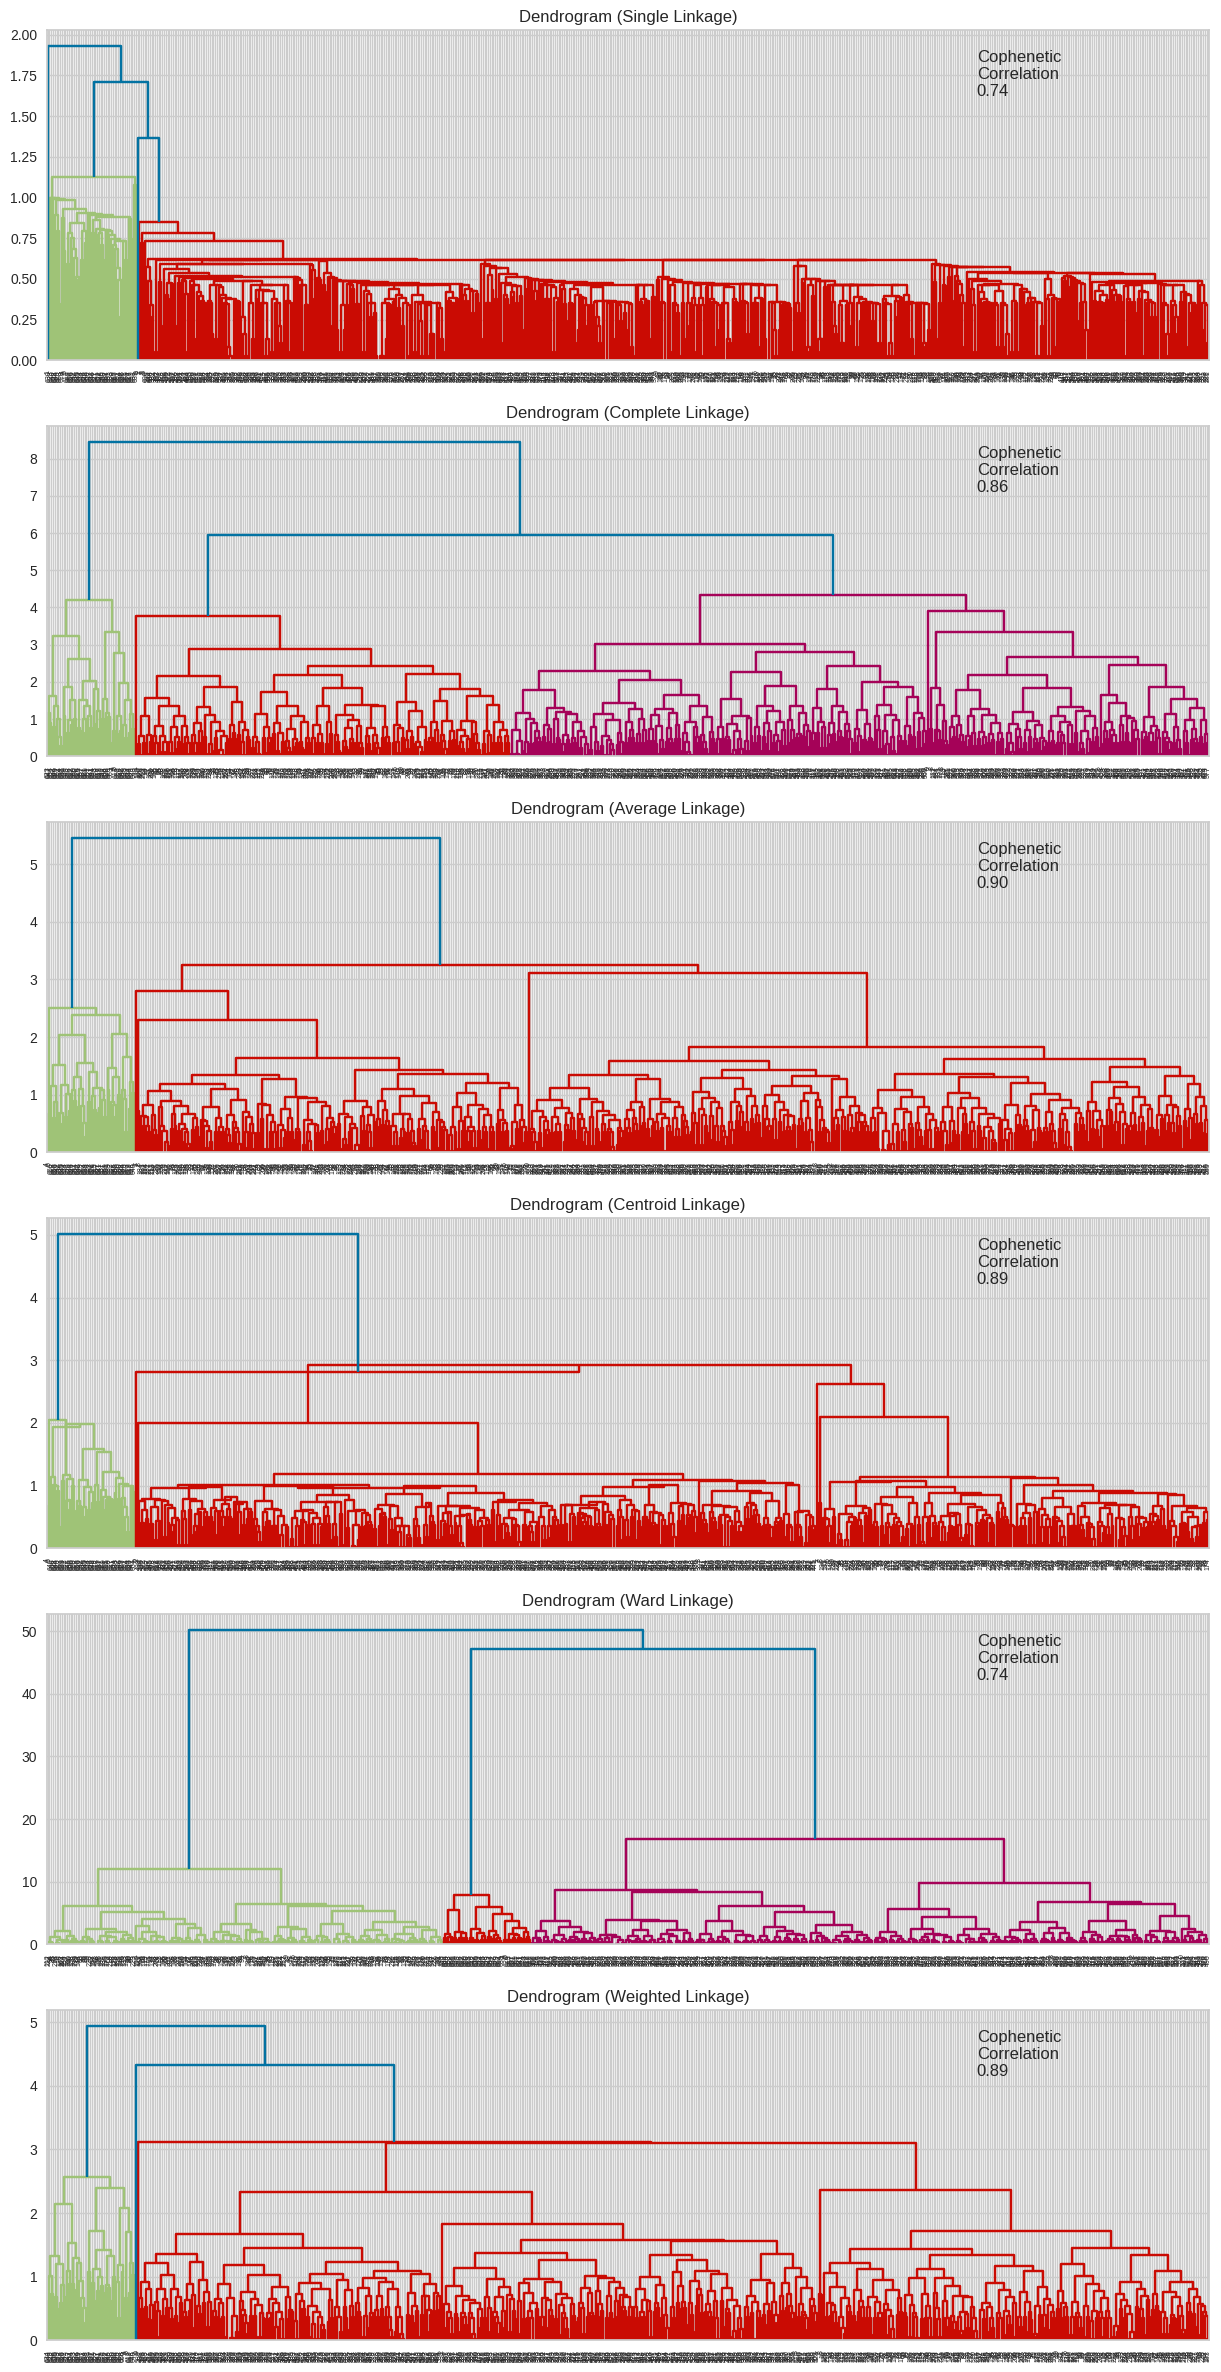

In [45]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

In [46]:
# let's create a dataframe to compare cophenetic correlations for each linkage method
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc

,Linkage,Cophenetic Coefficient
0,single,0.739122
1,complete,0.859973
2,average,0.897708
3,centroid,0.893939
4,ward,0.741516
5,weighted,0.886175


**Observations**

- The cophenetic correlation is highest for average and centroid linkage methods.
- We will move ahead with average linkage.
- 3 appears to be the appropriate number of clusters from the dendrogram for average linkage.

## Creating Final Model

In [48]:
HCmodel = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
HCmodel.fit(subset_scaled_df)

AgglomerativeClustering(linkage='average', n_clusters=3)

In [49]:
hc_df["HC_Clusters"] = HCmodel.labels_

In [50]:
hc_df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,HC_Clusters
0,100000,2,1,1,0,0
1,50000,3,0,10,9,2
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,1


## Cluster Profiling

In [48]:
cluster_profile = hc_df.groupby("HC_Clusters").mean(numeric_only = True)

In [49]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
HC_Clusters,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168
1,141040.000000,8.740000,0.600000,10.900000,1.080000
2,12197.309417,2.403587,0.928251,3.560538,6.883408


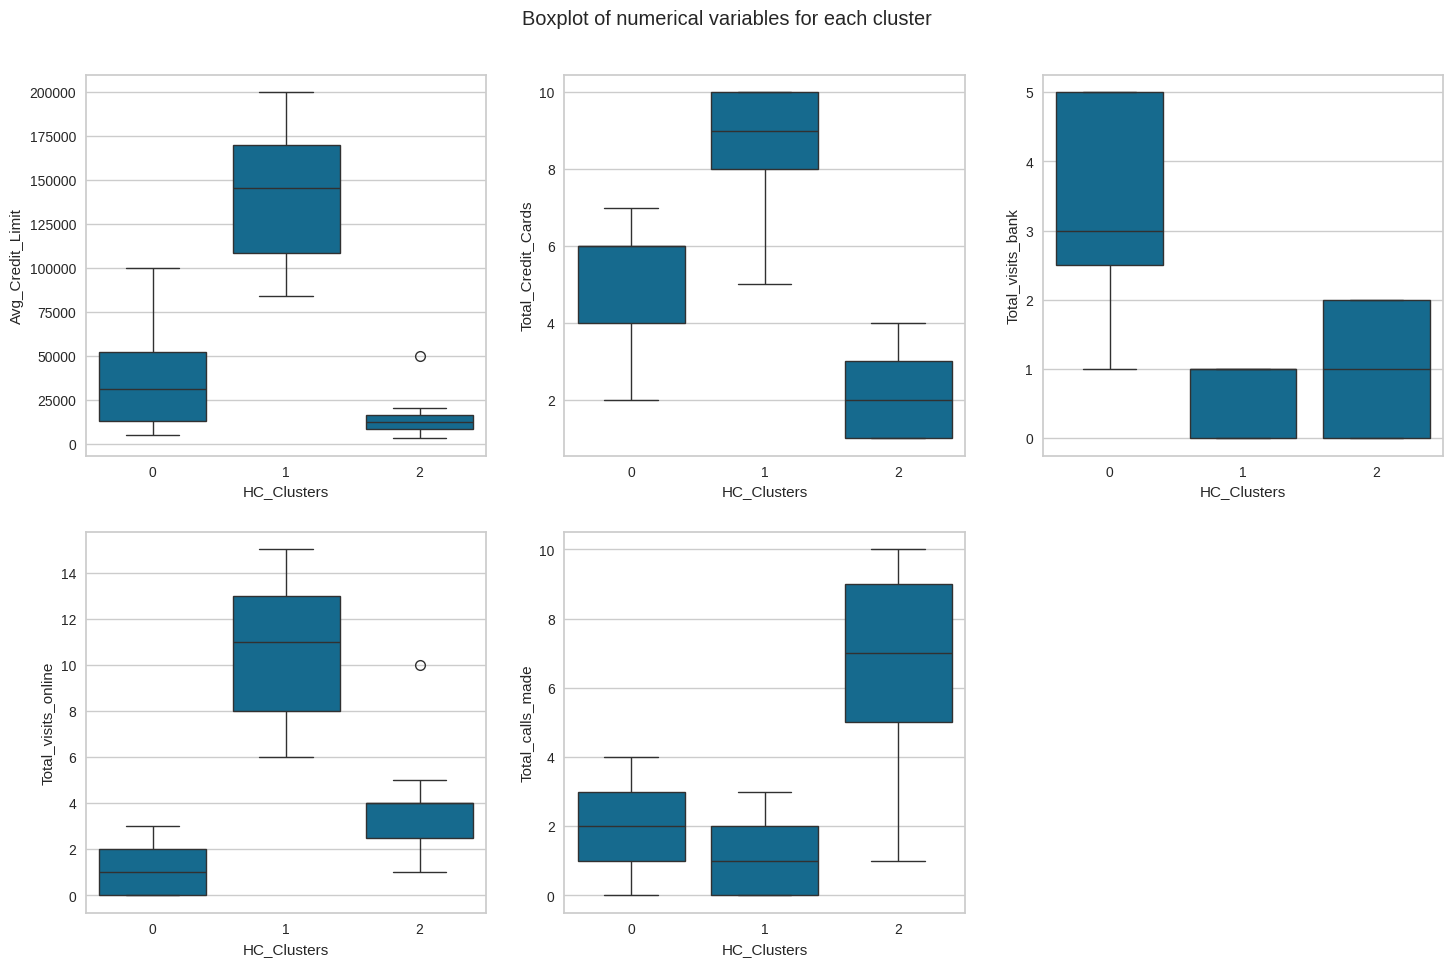

In [50]:
plt.figure(figsize=(15, 10))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(numeric_columns):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=hc_df, x="HC_Clusters", y=variable)

plt.tight_layout(pad=2.0)

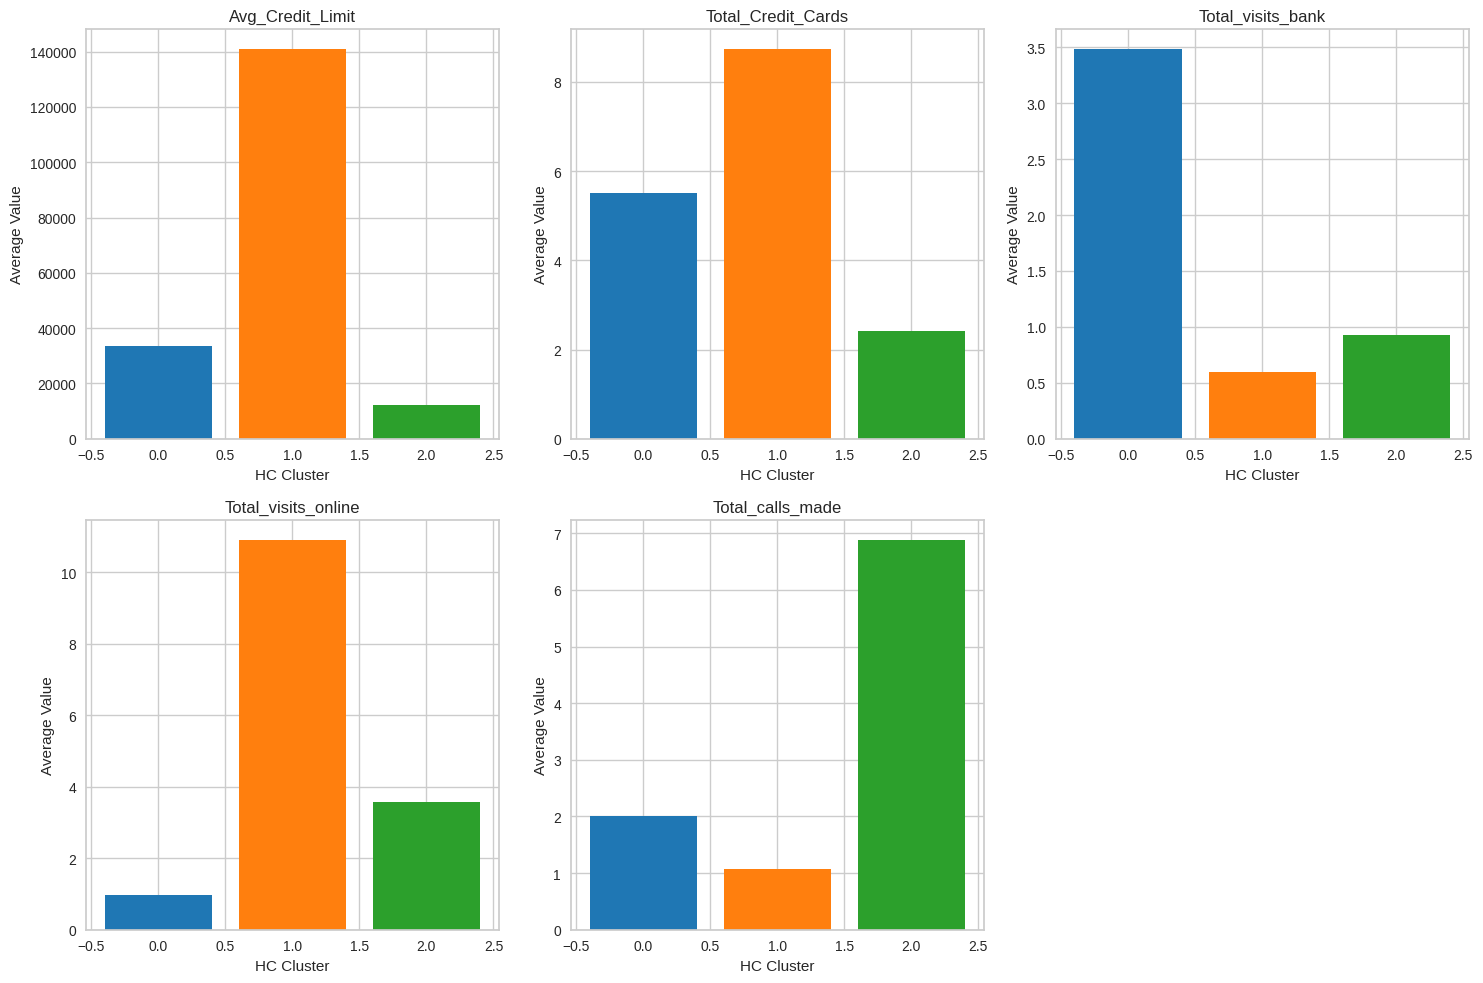

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Get hierarchical cluster profile
hc_profile = hc_df.groupby("HC_Clusters").mean()

clusters = hc_profile.index
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # blue, orange, green

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(hc_profile.columns):
    axes[i].bar(clusters, hc_profile[col], color=colors)
    axes[i].set_title(col)
    axes[i].set_xlabel("HC Cluster")
    axes[i].set_ylabel("Average Value")

#Remove extra subplot (since 5 features but 6 slots)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Cluster 0**

*  Medium credit limit
*  Moderate number of cards
*  Highest branch visits
*  Very low online usage
*  Moderate calls
*  prefer physical banking channels

**Cluster 1**

*  Very high credit limit
*  Highest number of cards
*  Low branch visits
*  Very high online usage
*  Very low calls
*  high-value, digitally active customers.

**Cluster 2**

*  Lowest credit limit
*  Fewest cards
*  Low branch visits
*  Moderate online usage
*  Highest calls
*  Frequently contact support

# **K-means vs Hierarchical Clustering**

In [ ]:
print("KMeans Silhouette:", silhouette_score(subset_scaled_df, km_df['Cluster']))
print("Hierarchical Silhouette:", silhouette_score(subset_scaled_df, hc_df['HC_Clusters']))


KMeans Silhouette: 0.5892124802251283
Hierarchical Silhouette: 0.590990473596407


Both K-Means and Hierarchical clustering achieved strong silhouette scores (~0.59), indicating well-defined and cohesive customer segments.

In [ ]:
from IPython.display import display

display(km_df.groupby('Cluster').mean())
display(hc_df.groupby('HC_Clusters').mean())

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000
1,12174.107143,2.410714,0.933036,3.553571,6.870536
2,141040.000000,8.740000,0.600000,10.900000,1.080000


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
HC_Clusters,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168
1,141040.000000,8.740000,0.600000,10.900000,1.080000
2,12197.309417,2.403587,0.928251,3.560538,6.883408


In [ ]:
from sklearn.metrics import adjusted_rand_score

print("ARI:", adjusted_rand_score(km_df['Cluster'], hc_df['HC_Clusters']))

ARI: 0.9943676076546543


The Adjusted Rand Index of 0.994 demonstrates near-perfect agreement between the two methods.

In [55]:
print("K-Means Cluster Sizes:")
print(km_df["Cluster"].value_counts().sort_index())

print("\nHierarchical Cluster Sizes:")
print(hc_df["HC_Clusters"].value_counts().sort_index())


K-Means Cluster Sizes:
Cluster
0    386
1    224
2     50
Name: count, dtype: int64

Hierarchical Cluster Sizes:
HC_Clusters
0    387
1     50
2    223
Name: count, dtype: int64


*  Looks like the K-Means and Hierarchical clusters are similar, except that the labels are swapped between clusters 1 and 2.

# **Actionable Insights & Recommendations**

Based on the clustering analysis, three distinct customer segments were identified. Each segment requires a differentiated strategy to maximize revenue, improve service quality, and optimize operational efficiency.


**Segment 1 - Traditional Moderate Customers**

These customers prefer physical branch interaction and show low digital adoption.(Branch-Dependent Customers)


**Recommendations:**

**Marketing Strategy**

*  Promote digital banking adoption campaigns
*  Offer incentives for mobile/app usage
*  Cross-sell mid-tier credit cards
*  Encourage autopay and digital statements

**Operations Strategy**

*  Educate customers on self-service options
*  Reduce dependency on physical branches
*  Improve onboarding to digital channels

🎯 Goal: Reduce servicing cost and improve digital penetration.

**Segment 2 - Premium Digital Customers**

High credit exposure, high engagement, low support dependency.(High-Value, Digitally Engaged Customers)


**Recommendations:**

**Marketing Strategy**

*  Target for premium card upgrades
*  Offer loyalty programs and exclusive benefits
*  Personalized reward programs
*  Early access to new financial products

**Operations Strategy**

*  Provide fast-track service options
*  Ensure seamless digital experience
*  Proactive retention campaigns

🎯 Goal: Maximize revenue and retain high-value customers.

**Segment 3 - Low Value, High Support Customers**

Low credit exposure but high support call frequency, increasing operational costs.(High Servicing Cost Segment)


**Recommendations:**

**Marketing Strategy**

*  Carefully evaluate upsell opportunities
*  Offer financial education programs
*  Promote low-risk credit products

**Operations Strategy**

*  Improve FAQ and chatbot automation
*  Strengthen first-call resolution
*  Provide guided digital tutorials
*  Analyze common call reasons to reduce volume

🎯 Goal: Reduce operational cost and improve customer satisfaction.

**Strategic Impact for AllLife Bank**

Implementing these segment-specific strategies will help the bank:

*  Increase targeted upselling success
*  Improve customer experience
*  Reduce operational support costs
*  Improve digital adoption rates
*  Strengthen customer retention
*  Optimize marketing ROI


By applying clustering techniques, three distinct credit card customer segments were identified that differ significantly in financial exposure and service interaction behavior. The clustering analysis provides a data-driven framework for personalized marketing and service optimization. By aligning marketing and operations strategies with customer segment behavior, AllLife Bank can enhance profitability while improving customer satisfaction and service efficiency.